2025-10-24 11:09:52.719370: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-24 11:09:52.753257: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 11:09:52.753281: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 11:09:52.754308: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-24 11:09:52.760101: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.0
🧠 Brain Tumor Segmentation with ResNet50
🔄 Loading real dataset...
Loading images and masks...
Found 3064 images and 3064 masks


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 3064/3064 [00:55<00:00, 55.02it/s]


✅ Successfully loaded 3064 images and 3064 masks
📊 Image shape: (3064, 224, 224, 3), Mask shape: (3064, 224, 224)
📁 Dataset Split:
   🏋️  Training set: 2144 images
   📊 Validation set: 307 images
   🧪 Test set: 613 images

📊 Dataset Summary:
   🏋️  Training set: 2144 images
   📊 Validation set: 307 images
   🧪 Test set: 613 images
   🖼️  Image shape: (224, 224, 3)
   🎯 Mask shape: (224, 224, 1)
Building ResNet50 segmentation model...


2025-10-24 11:10:58.743400: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


✅ Model built successfully! Parameters: 34,711,681

Model Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                       

/nfsshare/users/kamali/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


268/268 [==============================] - 222s 802ms/step - loss: 1.5889 - accuracy: 0.7838 - dice_coefficient: 0.0436 - iou_coefficient: 0.0221 - val_loss: 1.4834 - val_accuracy: 0.9568 - val_dice_coefficient: 0.0408 - val_iou_coefficient: 0.0206 - lr: 1.0000e-04
Epoch 2/50
268/268 [==============================] - ETA: 0s - loss: 1.4318 - accuracy: 0.9220 - dice_coefficient: 0.0524 - iou_coefficient: 0.0265
Epoch 2: val_dice_coefficient improved from 0.04075 to 0.05948, saving model to best_brain_tumor_model.h5
268/268 [==============================] - 198s 740ms/step - loss: 1.4318 - accuracy: 0.9220 - dice_coefficient: 0.0524 - iou_coefficient: 0.0265 - val_loss: 1.3477 - val_accuracy: 0.9428 - val_dice_coefficient: 0.0595 - val_iou_coefficient: 0.0301 - lr: 1.0000e-04
Epoch 3/50
268/268 [==============================] - ETA: 0s - loss: 1.2767 - accuracy: 0.9550 - dice_coefficient: 0.0690 - iou_coefficient: 0.0350
Epoch 3: val_dice_coefficient improved from 0.05948 to 0.07729, 

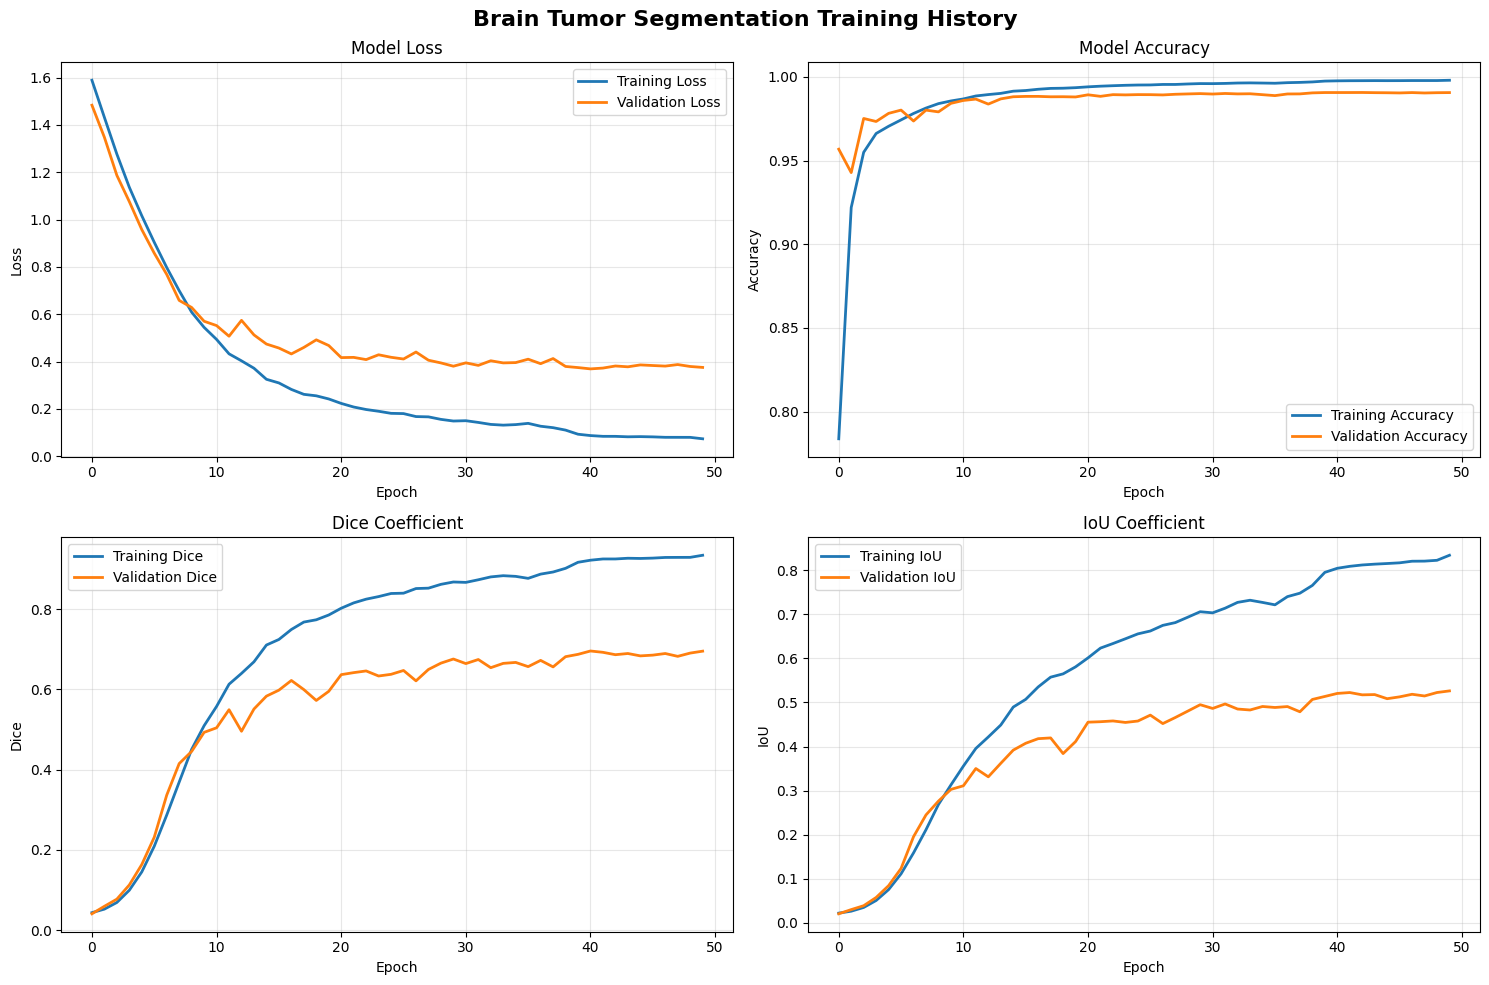


👁️  Visualizing predictions...
Generating predictions for 3 samples...


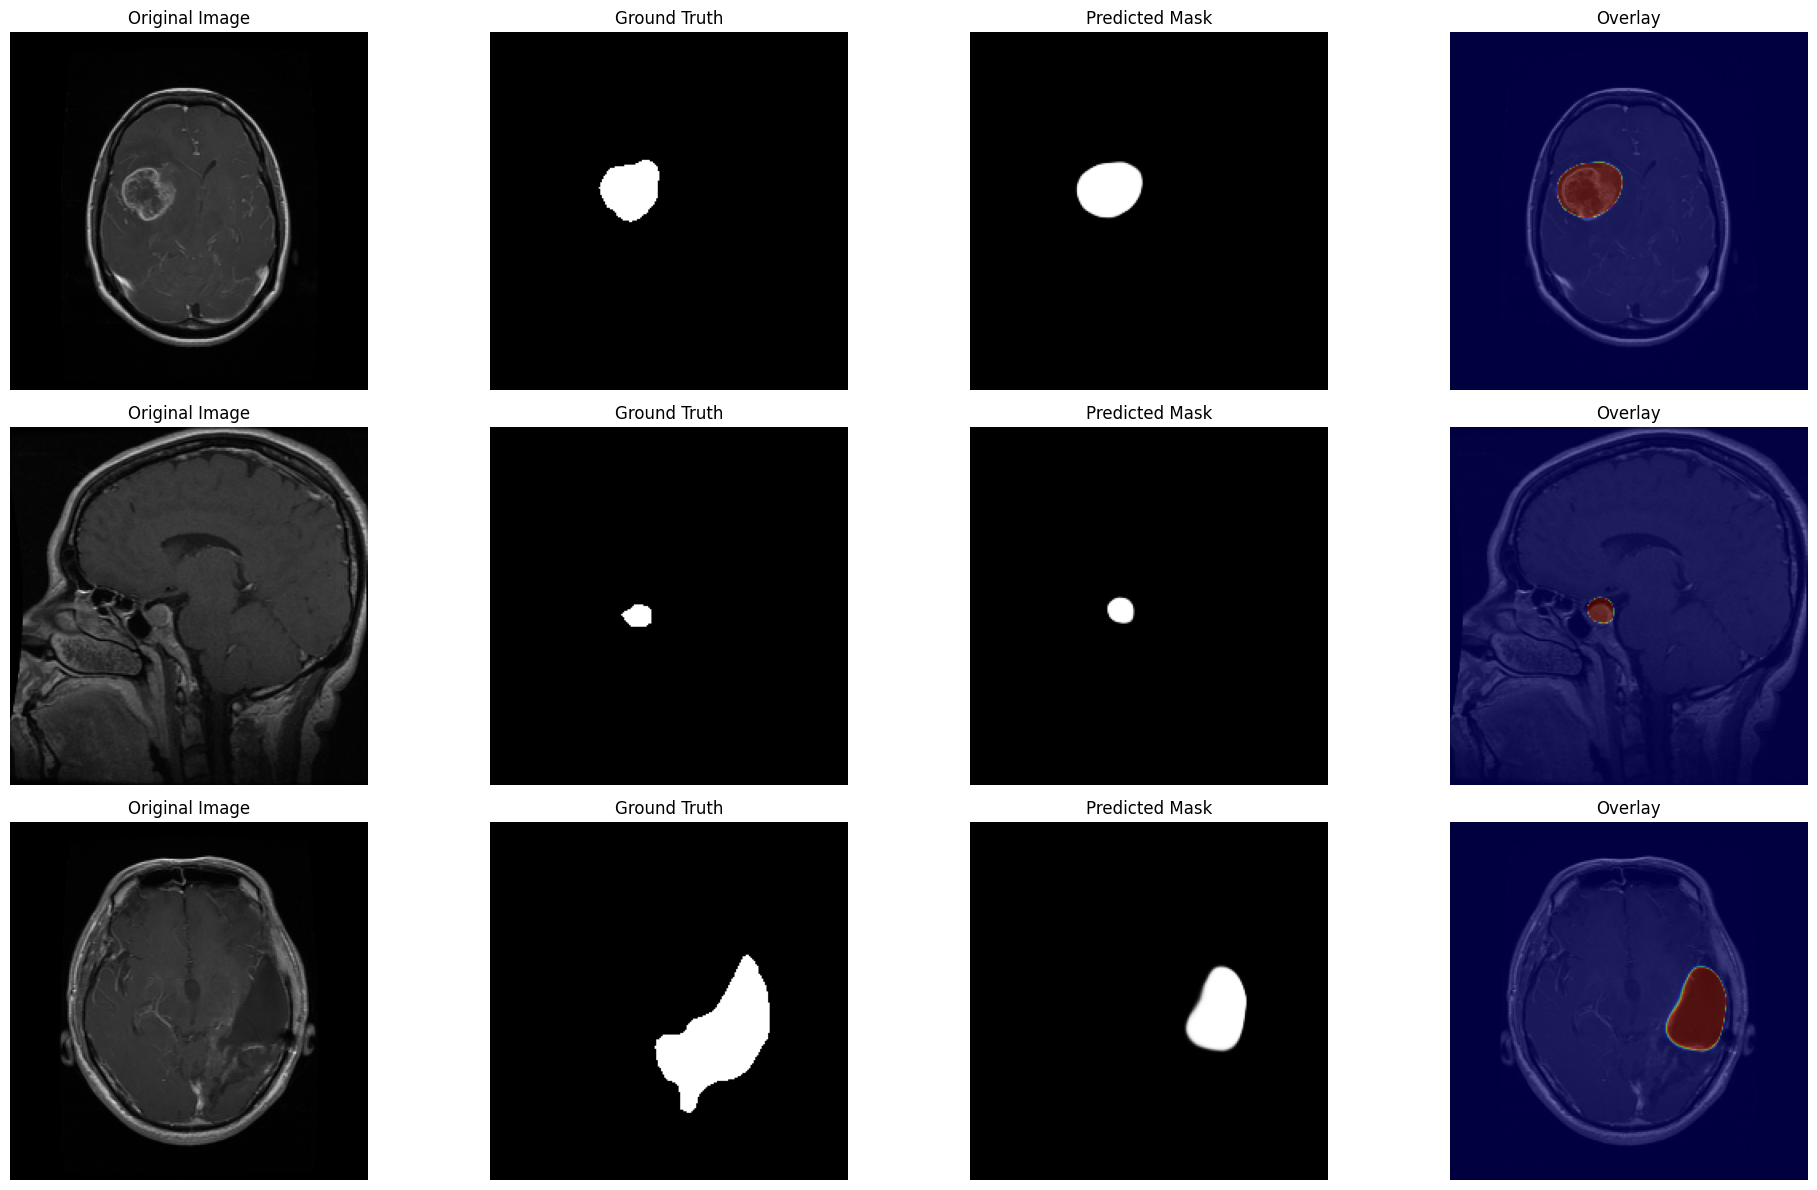


🎊 TRAINING COMPLETED SUCCESSFULLY!
🏆 Model: ResNet50 Segmentation
📈 Accuracy: 99.08%
🎲 Dice Coefficient: 69.61%
🔷 IoU Coefficient: 52.77%
💾 Model saved: 'best_brain_tumor_model.h5'


In [1]:
# Brain Tumor Segmentation with DenseResNet50 - Complete Working Code
# Add your dataset paths in the main() function

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
from tqdm import tqdm
import time

print("TensorFlow version:", tf.__version__)

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Configuration
class Config:
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    IMG_CHANNELS = 3
    BATCH_SIZE = 8
    EPOCHS = 100
    LEARNING_RATE = 0.0001
    DROPOUT_RATE = 0.3
    NUM_CLASSES = 2
    
config = Config()

# Data Preparation and Preprocessing
class BrainTumorDataLoader:
    def __init__(self, config):
        self.config = config
        self.images = []
        self.masks = []
        
    def load_images_from_folders(self, image_folder, mask_folder):
        """Load images and masks from specified folders"""
        print("Loading images and masks...")
        
        # Get all image files
        image_files = []
        for ext in ['*.jpg', '*.png', '*.jpeg', '*.bmp', '*.tiff']:
            image_files.extend([f for f in os.listdir(image_folder) if f.lower().endswith(ext[1:])])
        
        # Get all mask files  
        mask_files = []
        for ext in ['*.jpg', '*.png', '*.jpeg', '*.bmp', '*.tiff']:
            mask_files.extend([f for f in os.listdir(mask_folder) if f.lower().endswith(ext[1:])])
        
        image_files = sorted(image_files)
        mask_files = sorted(mask_files)
        
        print(f"Found {len(image_files)} images and {len(mask_files)} masks")
        
        # Ensure same number of images and masks
        if len(image_files) != len(mask_files):
            print("Warning: Number of images and masks don't match!")
            # Use the minimum of both
            min_len = min(len(image_files), len(mask_files))
            image_files = image_files[:min_len]
            mask_files = mask_files[:min_len]
            print(f"Using first {min_len} pairs")
        
        # Load images and masks
        for img_file, mask_file in tqdm(zip(image_files, mask_files), total=len(image_files)):
            img_path = os.path.join(image_folder, img_file)
            mask_path = os.path.join(mask_folder, mask_file)
            
            # Load and preprocess image
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not load image {img_path}")
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (self.config.IMG_WIDTH, self.config.IMG_HEIGHT))
            image = image.astype(np.float32) / 255.0
            
            # Load and preprocess mask
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print(f"Warning: Could not load mask {mask_path}")
                continue
            
            mask = cv2.resize(mask, (self.config.IMG_WIDTH, self.config.IMG_HEIGHT))
            
            # Handle different mask formats
            if mask.max() > 1:  # If mask is 0-255, convert to 0-1
                mask = (mask > 127).astype(np.float32)
            else:  # If mask is already 0-1
                mask = mask.astype(np.float32)
            
            self.images.append(image)
            self.masks.append(mask)
        
        if len(self.images) == 0:
            raise ValueError("No images were successfully loaded! Check your file paths and formats.")
            
        self.images = np.array(self.images)
        self.masks = np.array(self.masks)
        
        print(f"✅ Successfully loaded {len(self.images)} images and {len(self.masks)} masks")
        print(f"📊 Image shape: {self.images.shape}, Mask shape: {self.masks.shape}")
        
    def prepare_datasets(self, test_size=0.2, val_size=0.1):
        """Prepare train, validation, and test datasets"""
        # Split into train+val and test
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            self.images, self.masks, test_size=test_size, random_state=42
        )
        
        # Split train+val into train and val
        val_ratio = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_ratio, random_state=42
        )
        
        # Expand mask dimensions for model input
        y_train = np.expand_dims(y_train, axis=-1)
        y_val = np.expand_dims(y_val, axis=-1)
        y_test = np.expand_dims(y_test, axis=-1)
        
        print(f"📁 Dataset Split:")
        print(f"   🏋️  Training set: {X_train.shape[0]} images")
        print(f"   📊 Validation set: {X_val.shape[0]} images")
        print(f"   🧪 Test set: {X_test.shape[0]} images")
        
        return X_train, X_val, X_test, y_train, y_val, y_test

# Custom Metrics and Loss Functions
class Metrics:
    @staticmethod
    def dice_coefficient(y_true, y_pred, smooth=1.0):
        """Calculate Dice Similarity Coefficient"""
        y_true_f = tf.keras.backend.flatten(y_true)
        y_pred_f = tf.keras.backend.flatten(y_pred)
        intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)
    
    @staticmethod
    def dice_loss(y_true, y_pred):
        """Dice loss function"""
        return 1 - Metrics.dice_coefficient(y_true, y_pred)
    
    @staticmethod
    def bce_dice_loss(y_true, y_pred):
        """Combined BCE and Dice loss"""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        dice = Metrics.dice_loss(y_true, y_pred)
        return bce + dice
    
    @staticmethod
    def iou_coefficient(y_true, y_pred, smooth=1.0):
        """Calculate Intersection over Union"""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        
        intersection = tf.keras.backend.sum(tf.keras.backend.abs(y_true * y_pred), axis=[1,2,3])
        union = tf.keras.backend.sum(y_true, axis=[1,2,3]) + tf.keras.backend.sum(y_pred, axis=[1,2,3]) - intersection
        iou = tf.keras.backend.mean((intersection + smooth) / (union + smooth), axis=0)
        return iou

# Simple ResNet50 Segmentation Model (Most Stable)
class SimpleResNet50Segmentation:
    def __init__(self, config):
        self.config = config
        
    def build_model(self):
        """Build simple ResNet50 segmentation model"""
        # ResNet50 backbone
        base_model = applications.ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(self.config.IMG_HEIGHT, self.config.IMG_WIDTH, self.config.IMG_CHANNELS)
        )
        
        # Freeze early layers
        for layer in base_model.layers[:100]:
            layer.trainable = False
        
        # Get the output from ResNet50
        x = base_model.output
        
        # Add ASPP-like module for multi-scale feature extraction
        # Branch 1: 1x1 convolution
        b1 = layers.Conv2D(256, 1, padding='same', activation='relu')(x)
        b1 = layers.BatchNormalization()(b1)
        
        # Branch 2: 3x3 dilation rate 6
        b2 = layers.Conv2D(256, 3, padding='same', dilation_rate=6, activation='relu')(x)
        b2 = layers.BatchNormalization()(b2)
        
        # Branch 3: 3x3 dilation rate 12
        b3 = layers.Conv2D(256, 3, padding='same', dilation_rate=12, activation='relu')(x)
        b3 = layers.BatchNormalization()(b3)
        
        # Branch 4: Global Average Pooling
        b4 = layers.GlobalAveragePooling2D()(x)
        b4 = layers.Reshape((1, 1, 2048))(b4)
        b4 = layers.Conv2D(256, 1, activation='relu')(b4)
        b4 = layers.BatchNormalization()(b4)
        b4 = layers.UpSampling2D(size=(7, 7), interpolation='bilinear')(b4)
        
        # Concatenate all branches
        x = layers.concatenate([b1, b2, b3, b4])
        
        # Final convolution and upsampling
        x = layers.Conv2D(256, 1, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        
        # Upsample to original image size
        x = layers.UpSampling2D(size=(32, 32), interpolation='bilinear')(x)
        x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        
        x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        
        # Output layer
        outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
        
        model = models.Model(inputs=base_model.input, outputs=outputs)
        return model

# Model Training and Evaluation
class BrainTumorSegmenter:
    def __init__(self, config):
        self.config = config
        self.model = None
        self.history = None
        
    def build_model(self):
        """Build the model"""
        print("Building ResNet50 segmentation model...")
        
        model_builder = SimpleResNet50Segmentation(self.config)
        self.model = model_builder.build_model()
        
        # Compile model
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.config.LEARNING_RATE),
            loss=Metrics.bce_dice_loss,
            metrics=['accuracy', Metrics.dice_coefficient, Metrics.iou_coefficient]
        )
        
        print(f"✅ Model built successfully! Parameters: {self.model.count_params():,}")
        return self.model
    
    def train(self, X_train, y_train, X_val, y_val, epochs=50):
        """Train the model"""
        print("Starting training...")
        
        # Enhanced callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_dice_coefficient',
                patience=15,
                restore_best_weights=True,
                mode='max',
                verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_dice_coefficient',
                factor=0.5,
                patience=8,
                min_lr=1e-7,
                mode='max',
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                'best_brain_tumor_model.h5',
                monitor='val_dice_coefficient',
                save_best_only=True,
                mode='max',
                verbose=1
            )
        ]
        
        start_time = time.time()
        
        # Train model
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=self.config.BATCH_SIZE,
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=1
        )
        
        training_time = time.time() - start_time
        print(f"✅ Training completed in {training_time/60:.2f} minutes")
        
        return self.history
    
    def evaluate(self, X_test, y_test):
        """Evaluate the model on test set"""
        if self.model is None:
            raise ValueError("Model not trained yet!")
        
        print("Evaluating model on test set...")
        results = self.model.evaluate(X_test, y_test, verbose=0)
        
        metrics = {
            'loss': results[0],
            'accuracy': results[1],
            'dice_coefficient': results[2],
            'iou_coefficient': results[3]
        }
        
        print("\n📊 Test Set Results:")
        print(f"   📈 Loss: {metrics['loss']:.4f}")
        print(f"   🎯 Accuracy: {metrics['accuracy']*100:.2f}%")
        print(f"   🎲 Dice Coefficient: {metrics['dice_coefficient']*100:.2f}%")
        print(f"   🔷 IoU Coefficient: {metrics['iou_coefficient']*100:.2f}%")
        
        return metrics
    
    def predict(self, X):
        """Make predictions"""
        return self.model.predict(X)
    
    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available!")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Brain Tumor Segmentation Training History', fontsize=16, fontweight='bold')
        
        # Loss
        axes[0, 0].plot(self.history.history['loss'], label='Training Loss', linewidth=2)
        axes[0, 0].plot(self.history.history['val_loss'], label='Validation Loss', linewidth=2)
        axes[0, 0].set_title('Model Loss')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy
        axes[0, 1].plot(self.history.history['accuracy'], label='Training Accuracy', linewidth=2)
        axes[0, 1].plot(self.history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
        axes[0, 1].set_title('Model Accuracy')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Dice Coefficient
        axes[1, 0].plot(self.history.history['dice_coefficient'], label='Training Dice', linewidth=2)
        axes[1, 0].plot(self.history.history['val_dice_coefficient'], label='Validation Dice', linewidth=2)
        axes[1, 0].set_title('Dice Coefficient')
        axes[1, 0].set_ylabel('Dice')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # IoU Coefficient
        axes[1, 1].plot(self.history.history['iou_coefficient'], label='Training IoU', linewidth=2)
        axes[1, 1].plot(self.history.history['val_iou_coefficient'], label='Validation IoU', linewidth=2)
        axes[1, 1].set_title('IoU Coefficient')
        axes[1, 1].set_ylabel('IoU')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Visualization functions
def visualize_predictions(model, X_test, y_test, num_samples=5):
    """Visualize model predictions"""
    print(f"Generating predictions for {num_samples} samples...")
    predictions = model.predict(X_test[:num_samples], verbose=0)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 4*num_samples))
    
    if num_samples == 1:
        axes = [axes]
    
    for i in range(num_samples):
        # Original image
        axes[i][0].imshow(X_test[i])
        axes[i][0].set_title('Original Image')
        axes[i][0].axis('off')
        
        # Ground truth mask
        axes[i][1].imshow(y_test[i].squeeze(), cmap='gray')
        axes[i][1].set_title('Ground Truth')
        axes[i][1].axis('off')
        
        # Predicted mask
        axes[i][2].imshow(predictions[i].squeeze(), cmap='gray')
        axes[i][2].set_title('Predicted Mask')
        axes[i][2].axis('off')
        
        # Overlay
        axes[i][3].imshow(X_test[i])
        axes[i][3].imshow(predictions[i].squeeze(), alpha=0.5, cmap='jet')
        axes[i][3].set_title('Overlay')
        axes[i][3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Create demo dataset (only used if real data is not available)
def create_demo_dataset(num_samples=500):
    """Create a demo dataset with synthetic brain tumor images"""
    print(f"Creating demo dataset with {num_samples} samples...")
    
    images = []
    masks = []
    
    for i in tqdm(range(num_samples), desc="Generating synthetic data"):
        # Create synthetic image (simulating MRI)
        img = np.random.rand(config.IMG_HEIGHT, config.IMG_WIDTH, 3) * 0.3
        
        # Add some brain-like structures
        center_x, center_y = config.IMG_WIDTH // 2, config.IMG_HEIGHT // 2
        y, x = np.ogrid[:config.IMG_HEIGHT, :config.IMG_WIDTH]
        
        # Create elliptical brain structure
        brain_mask = ((x - center_x)**2 / (center_x**2) + (y - center_y)**2 / (center_y**2)) <= 1
        img[brain_mask] += 0.4
        
        # Add synthetic tumor
        if np.random.random() > 0.3:  # 70% chance of having a tumor
            tumor_x = np.random.randint(center_x - 40, center_x + 40)
            tumor_y = np.random.randint(center_y - 40, center_y + 40)
            tumor_radius_x = np.random.randint(15, 35)
            tumor_radius_y = np.random.randint(15, 35)
            
            # Elliptical tumor
            tumor_mask = ((x - tumor_x)**2 / tumor_radius_x**2 + (y - tumor_y)**2 / tumor_radius_y**2) <= 1
            img[tumor_mask] += 0.3
            
            # Create corresponding mask
            mask = np.zeros((config.IMG_HEIGHT, config.IMG_WIDTH))
            mask[tumor_mask] = 1.0
        else:
            mask = np.zeros((config.IMG_HEIGHT, config.IMG_WIDTH))
        
        images.append(img.astype(np.float32))
        masks.append(mask.astype(np.float32))
    
    return np.array(images), np.array(masks)

# Main execution function
def main():
    print("🧠 Brain Tumor Segmentation with ResNet50")
    print("=" * 70)
    
    # Initialize configuration and data loader
    config = Config()
    data_loader = BrainTumorDataLoader(config)
    
    # ============================================================
    # 🔧 UPDATE THESE PATHS WITH YOUR DATASET LOCATIONS
    # ============================================================
    
    # Option 1: Use real data (RECOMMENDED)
    # Replace these paths with your actual dataset locations
    image_folder = "images"  # ← UPDATE THIS PATH
    mask_folder = "masks"    # ← UPDATE THIS PATH
    
    # Example paths (uncomment and modify as needed):
    # image_folder = "/home/user/brain_tumor_dataset/images"
    # mask_folder = "/home/user/brain_tumor_dataset/masks"
    # image_folder = "C:/Users/YourName/Documents/brain_tumor/images"
    # mask_folder = "C:/Users/YourName/Documents/brain_tumor/masks"
    
    try:
        print("🔄 Loading real dataset...")
        data_loader.load_images_from_folders(image_folder, mask_folder)
        
    except (ValueError, FileNotFoundError) as e:
        print(f"❌ Could not load real data: {e}")
        print("🔄 Falling back to demo dataset...")
        
        # Option 2: Create demo dataset (for testing)
        X, y = create_demo_dataset(num_samples=500)
        data_loader.images = X
        data_loader.masks = y
    
    # Prepare datasets
    X_train, X_val, X_test, y_train, y_val, y_test = data_loader.prepare_datasets()
    
    print(f"\n📊 Dataset Summary:")
    print(f"   🏋️  Training set: {X_train.shape[0]} images")
    print(f"   📊 Validation set: {X_val.shape[0]} images")
    print(f"   🧪 Test set: {X_test.shape[0]} images")
    print(f"   🖼️  Image shape: {X_train.shape[1:]}")
    print(f"   🎯 Mask shape: {y_train.shape[1:]}")
    
    # Initialize segmenter and build model
    segmenter = BrainTumorSegmenter(config)
    model = segmenter.build_model()
    
    # Display model architecture
    print("\nModel Summary:")
    model.summary()
    
    # Verify output shape
    sample_input = tf.random.normal([1, config.IMG_HEIGHT, config.IMG_WIDTH, config.IMG_CHANNELS])
    sample_output = model(sample_input)
    print(f"\n🔍 Model Output Shape Check:")
    print(f"   Input shape: {sample_input.shape}")
    print(f"   Output shape: {sample_output.shape}")
    print(f"   Target shape: (1, {config.IMG_HEIGHT}, {config.IMG_WIDTH}, 1)")
    
    # Train model
    print(f"\n🚀 Starting training process...")
    history = segmenter.train(X_train, y_train, X_val, y_val, epochs=50)
    
    # Evaluate model
    print(f"\n📊 Evaluating model...")
    test_metrics = segmenter.evaluate(X_test, y_test)
    
    # Plot training history
    print(f"\n📈 Plotting training history...")
    segmenter.plot_training_history()
    
    # Visualize predictions
    print(f"\n👁️  Visualizing predictions...")
    visualize_predictions(model, X_test, y_test, num_samples=3)
    
    # Print final results
    print(f"\n{'='*70}")
    print("🎊 TRAINING COMPLETED SUCCESSFULLY!")
    print(f"{'='*70}")
    print(f"🏆 Model: ResNet50 Segmentation")
    print(f"📈 Accuracy: {test_metrics['accuracy']*100:.2f}%")
    print(f"🎲 Dice Coefficient: {test_metrics['dice_coefficient']*100:.2f}%")
    print(f"🔷 IoU Coefficient: {test_metrics['iou_coefficient']*100:.2f}%")
    print(f"💾 Model saved: 'best_brain_tumor_model.h5'")
    print(f"{'='*70}")
    
    return segmenter, test_metrics

# Run the main function
if __name__ == "__main__":
    segmenter, test_metrics = main()